## 1. Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    silhouette_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Upload the Two CSV Files

In [37]:
from google.colab import files

uploaded = files.upload()

# Upload:
# Loan_Approval_Data_Set_1.csv
# Loan_Approval_Data_Set_2.csv

Saving Loan_Approval_Data_Set_1.csv to Loan_Approval_Data_Set_1 (1).csv
Saving Loan_Approval_Data_Set_2.csv to Loan_Approval_Data_Set_2 (1).csv


## 3. Load the Datasets

In [38]:
data1 = pd.read_csv("Loan_Approval_Data_Set_1.csv")
data2 = pd.read_csv("Loan_Approval_Data_Set_2.csv")

print("Dataset 1 shape:", data1.shape)
print("Dataset 2 shape:", data2.shape)

display(data1.head())
display(data2.head())

Dataset 1 shape: (20000, 16)
Dataset 2 shape: (20000, 18)


,ID,ApplicationDate,AnnualIncome,EmploymentStatus,Experience,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1


,ApplicationDate,Age,CreditScore,EducationLevel,Experience,LoanAmount,MaritalStatus,HomeOwnershipStatus,ID,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,01-01-2018,45,617,Master,22.0,13152,Married,Own,A001,35.40,2,Home,29,7632,146111,11,22.75,49
1,02-01-2018,38,628,Associate,NaN,26045,Single,Mortgage,A002,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,XX
2,03-01-2018,47,570,Bachelor,26.0,17627,Married,Rent,A003,13.70,0,Education,20,886,25176,6,21.25,XX
3,04-01-2018,58,545,High School,34.0,37898,Single,Mortgage,A004,2.67,1,Home,27,1675,104822,5,30.09,54
4,05-01-2018,37,594,Associate,17.0,9184,Married,Mortgage,A005,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36


## 4. Fundamental Data Understanding

In [ ]:
print("DATASET 1")
print("-" * 50)
print("Rows:", data1.shape[0])
print("Columns:", data1.shape[1])
print("\nData types:")
print(data1.dtypes)
print("\nMissing values:")
print(data1.isnull().sum())
print("\nDuplicate rows:", data1.duplicated().sum())
print("\nDuplicate IDs:", data1["ID"].duplicated().sum())

print("\n\nDATASET 2")
print("-" * 50)
print("Rows:", data2.shape[0])
print("Columns:", data2.shape[1])
print("\nData types:")
print(data2.dtypes)
print("\nMissing values:")
print(data2.isnull().sum())
print("\nDuplicate rows:", data2.duplicated().sum())
print("\nDuplicate IDs:", data2["ID"].duplicated().sum())

DATASET 1
--------------------------------------------------
Rows: 20000
Columns: 16

Data types:
ID                         object
ApplicationDate            object
AnnualIncome                int64
EmploymentStatus           object
Experience                  int64
LoanDuration                int64
NumberOfDependents          int64
MonthlyDebtPayments         int64
NumberOfOpenCreditLines     int64
BankruptcyHistory           int64
PreviousLoanDefaults        int64
LengthOfCreditHistory       int64
CheckingAccountBalance      int64
TotalLiabilities            int64
NetWorth                    int64
LoanApproved                int64
dtype: object

Missing values:
ID                         0
ApplicationDate            0
AnnualIncome               0
EmploymentStatus           0
Experience                 0
LoanDuration               0
NumberOfDependents         0
MonthlyDebtPayments        0
NumberOfOpenCreditLines    0
BankruptcyHistory          0
PreviousLoanDefaults       0
LengthOf

### Data-quality issues found in the supplied files

With these datasets, you should observe:

- `ID` is unique in both files, so it can be used as the merge key.
- `RiskScore` contains text values such as `XX`.
- `Experience` has missing values in Dataset 2.
- `MaritalStatus` has a small number of missing values.
- The `ApplicationDate` field is present in both datasets and many records do not match.

The following cells handle these issues explicitly.

## 5. Clean `RiskScore` and `MaritalStatus`

In [ ]:
data2_clean = data2.copy()

# RiskScore should be numeric.
# errors='coerce' changes invalid text such as XX into NaN.
data2_clean["RiskScore"] = pd.to_numeric(
    data2_clean["RiskScore"],
    errors="coerce"
)

risk_missing = data2_clean["RiskScore"].isna().sum()
risk_median = data2_clean["RiskScore"].median()

print("Invalid/missing RiskScore values:", risk_missing)
print("RiskScore median:", risk_median)

# Median is used because RiskScore is numeric and
# the median is less sensitive to extreme values.
data2_clean["RiskScore"] = data2_clean["RiskScore"].fillna(
    risk_median
)

# MaritalStatus is categorical.
marital_missing = data2_clean["MaritalStatus"].isna().sum()
marital_mode = data2_clean["MaritalStatus"].mode()[0]

print("Missing MaritalStatus values:", marital_missing)
print("MaritalStatus mode:", marital_mode)

data2_clean["MaritalStatus"] = data2_clean["MaritalStatus"].fillna(
    marital_mode
)

Invalid/missing RiskScore values: 1275
RiskScore median: 51.0
Missing MaritalStatus values: 15
MaritalStatus mode: Married


## 6. Merge the Two Datasets Using `ID`

In [ ]:
# Remove exact duplicate rows before merging.
data1_clean = data1.drop_duplicates().copy()
data2_clean = data2_clean.drop_duplicates().copy()

# ID is unique in both datasets.
merged = pd.merge(
    data1_clean,
    data2_clean,
    on="ID",
    how="inner",
    suffixes=("_Set1", "_Set2")
)

print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (20000, 33)


,ID,ApplicationDate_Set1,AnnualIncome,EmploymentStatus,Experience_Set1,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,...,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,...,Own,35.40,2,Home,29,7632,146111,11,22.75,49.0
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,...,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,51.0
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,...,Rent,13.70,0,Education,20,886,25176,6,21.25,51.0
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,...,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54.0
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,...,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36.0


## 7. Handle `Experience` and `ApplicationDate` After Merging

In [ ]:
# Check missing Experience in Dataset 2.
missing_experience = merged["Experience_Set2"].isna().sum()
print("Missing Experience in Dataset 2:", missing_experience)

# When Dataset 2 Experience is missing,
# recover it from Dataset 1 using the same applicant ID.
merged["Experience"] = merged["Experience_Set2"].fillna(
    merged["Experience_Set1"]
)

# Check how many ApplicationDate values disagree.
date_mismatch = (
    merged["ApplicationDate_Set1"]
    != merged["ApplicationDate_Set2"]
).sum()

print("ApplicationDate mismatches:", date_mismatch)

# Use Dataset 1 as the consistent source for ApplicationDate.
merged["ApplicationDate"] = pd.to_datetime(
    merged["ApplicationDate_Set1"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Drop the duplicate versions of these fields.
merged = merged.drop(
    columns=[
        "Experience_Set1",
        "Experience_Set2",
        "ApplicationDate_Set1",
        "ApplicationDate_Set2"
    ]
)

print("Shape after resolving duplicated columns:", merged.shape)

Missing Experience in Dataset 2: 666
ApplicationDate mismatches: 17078
Shape after resolving duplicated columns: (20000, 31)


## 8. Feature Engineering

In [ ]:
# Monthly income
merged["Monthlyincome"] = (
    merged["AnnualIncome"] / 12
)

# Monthly loan payment using a standard loan amortisation formula.
principal = merged["LoanAmount"].astype(float)

monthly_rate = (
    merged["InterestRate"].astype(float)
    / 100
    / 12
)

months = (
    merged["LoanDuration"]
    .astype(float)
    .replace(0, np.nan)
)

merged["Monthlyloanpyament"] = np.where(
    monthly_rate == 0,
    principal / months,
    principal
    * (
        monthly_rate
        * (1 + monthly_rate) ** months
    )
    / (
        (1 + monthly_rate) ** months - 1
    )
)

# Total debt-to-income ratio required by the brief.
merged["Totaldebttoincomeratio"] = (
    (
        merged["Monthlyloanpyament"]
        + merged["MonthlyDebtPayments"]
    )
    * 100
    / merged["Monthlyincome"].replace(0, np.nan)
)

display(
    merged[
        [
            "AnnualIncome",
            "Monthlyincome",
            "LoanAmount",
            "Monthlyloanpyament",
            "MonthlyDebtPayments",
            "Totaldebttoincomeratio"
        ]
    ].head()
)

,AnnualIncome,Monthlyincome,LoanAmount,Monthlyloanpyament,MonthlyDebtPayments,Totaldebttoincomeratio
0,39948,3329.000000,13152,419.741550,183,18.105784
1,39709,3309.083333,26045,793.947113,496,38.982008
2,40724,3393.666667,17627,666.363154,902,46.214414
3,69084,5757.000000,37898,1047.478283,755,31.309333
4,103264,8605.333333,9184,330.137727,274,7.020503


## 9. Final Cleaning Check

In [ ]:
# Remove any remaining exact duplicate rows.
cleaned_data = merged.drop_duplicates().copy()

print("Final rows:", cleaned_data.shape[0])
print("Final columns:", cleaned_data.shape[1])
print("Duplicate rows:", cleaned_data.duplicated().sum())
print("Total missing values:", cleaned_data.isnull().sum().sum())

print("\nMissing values by column:")
print(
    cleaned_data.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Final rows: 20000
Final columns: 34
Duplicate rows: 0
Total missing values: 0

Missing values by column:
ID                         0
AnnualIncome               0
EmploymentStatus           0
LoanDuration               0
NumberOfDependents         0
MonthlyDebtPayments        0
NumberOfOpenCreditLines    0
BankruptcyHistory          0
PreviousLoanDefaults       0
LengthOfCreditHistory      0
CheckingAccountBalance     0
TotalLiabilities           0
NetWorth                   0
LoanApproved               0
Age                        0
dtype: int64


## 10. Outlier Review Using the IQR Method

In [ ]:
outlier_columns = [
    "AnnualIncome",
    "LoanAmount",
    "MonthlyDebtPayments",
    "NetWorth",
    "Totaldebttoincomeratio"
]

outlier_results = []

for column in outlier_columns:
    series = cleaned_data[column].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (series < lower_bound)
        | (series > upper_bound)
    ).sum()

    outlier_results.append([
        column,
        lower_bound,
        upper_bound,
        outlier_count
    ])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=[
        "Column",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

display(outlier_table)

# In this banking dataset, extreme financial values are not
# automatically removed because some may be genuine customers.

,Column,Lower Bound,Upper Bound,Outlier Count
0,AnnualIncome,-32389.000000,138459.000000,947
1,LoanAmount,-7315.000000,53725.000000,746
2,MonthlyDebtPayments,-131.000000,981.000000,744
3,NetWorth,-111401.375000,208961.625000,1564
4,Totaldebttoincomeratio,-31.475956,100.091279,1146


## 11. Save the Cleaned Dataset

In [ ]:
cleaned_data.to_csv(
    "cleaned_loan_data.csv",
    index=False
)

print("cleaned_loan_data.csv saved.")

cleaned_loan_data.csv saved.


# Exploratory Data Analysis (EDA)

## 12. Statistical Summary

In [ ]:
numeric_data = cleaned_data.select_dtypes(
    include=np.number
)

display(
    numeric_data.describe().T.round(2)
)

,count,mean,std,min,25%,50%,75%,max
AnnualIncome,20000.0,59161.47,40350.85,15000.00,31679.00,48566.00,74391.00,485341.00
LoanDuration,20000.0,54.06,24.66,12.00,36.00,48.00,72.00,120.00
NumberOfDependents,20000.0,1.52,1.39,0.00,0.00,1.00,2.00,5.00
MonthlyDebtPayments,20000.0,454.29,240.51,50.00,286.00,402.00,564.00,2919.00
NumberOfOpenCreditLines,20000.0,3.02,1.74,0.00,2.00,3.00,4.00,13.00
BankruptcyHistory,20000.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00
PreviousLoanDefaults,20000.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
LengthOfCreditHistory,20000.0,14.96,8.37,1.00,8.00,15.00,22.00,29.00
CheckingAccountBalance,20000.0,1782.56,2245.38,24.00,551.00,1116.00,2126.00,52572.00
TotalLiabilities,20000.0,36252.41,47251.51,372.00,11196.75,22203.00,43146.50,1417302.00


## 13. Loan Approval Distribution – Univariate Analysis

LoanApproved
0    15220
1     4780
Name: count, dtype: int64
Approval rate: 23.9 %


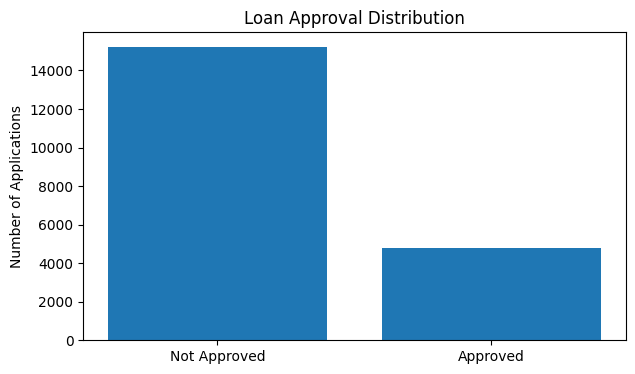

In [ ]:
approval_counts = (
    cleaned_data["LoanApproved"]
    .value_counts()
    .sort_index()
)

print(approval_counts)
print(
    "Approval rate:",
    round(
        cleaned_data["LoanApproved"].mean() * 100,
        2
    ),
    "%"
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    ["Not Approved", "Approved"],
    [
        approval_counts.get(0, 0),
        approval_counts.get(1, 0)
    ]
)

ax.set_title("Loan Approval Distribution")
ax.set_ylabel("Number of Applications")

plt.show()

## 14. Annual Income Distribution – Univariate Analysis

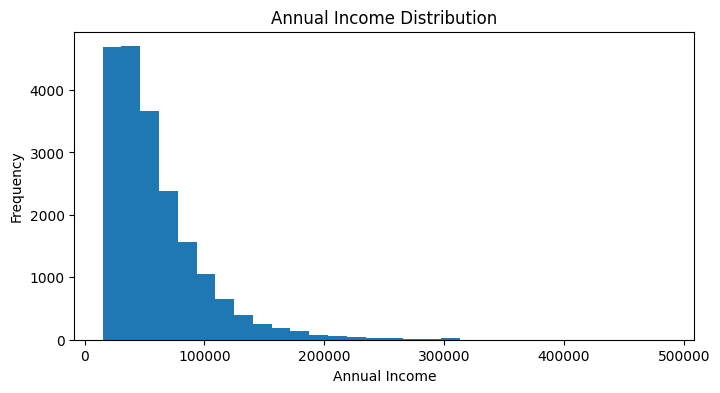

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    cleaned_data["AnnualIncome"].dropna(),
    bins=30
)

ax.set_title("Annual Income Distribution")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Frequency")

plt.show()

## 15. Approved vs Not Approved – Bivariate Analysis

In [ ]:
variables = [
    "CreditScore",
    "RiskScore",
    "AnnualIncome",
    "LoanAmount",
    "Totaldebttoincomeratio"
]

approval_comparison = (
    cleaned_data
    .groupby("LoanApproved")[variables]
    .mean()
    .T
)

approval_comparison.columns = [
    "Not Approved Mean",
    "Approved Mean"
]

display(
    approval_comparison.round(2)
)

,Not Approved Mean,Approved Mean
CreditScore,567.55,584.53
RiskScore,54.02,39.73
AnnualIncome,45641.46,102210.55
LoanAmount,26685.00,19144.71
Totaldebttoincomeratio,47.81,15.33


## 16. Approval Rate by Employment Status

,Approval Rate %
EmploymentStatus,
Self-Employed,27.84
Employed,24.00
Unemployed,18.19


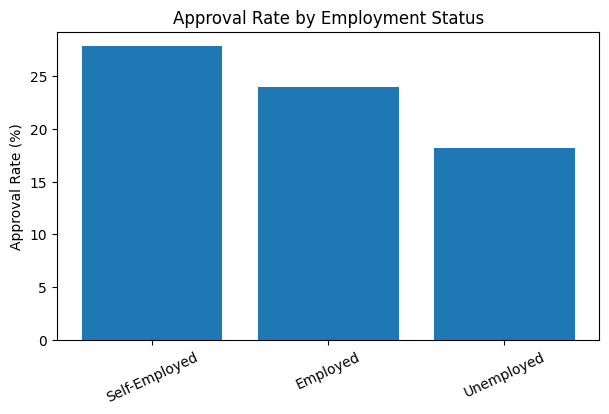

In [ ]:
employment_approval = (
    cleaned_data
    .groupby("EmploymentStatus")["LoanApproved"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    employment_approval.to_frame(
        "Approval Rate %"
    ).round(2)
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    employment_approval.index.astype(str),
    employment_approval.values
)

ax.set_title("Approval Rate by Employment Status")
ax.set_ylabel("Approval Rate (%)")
ax.tick_params(axis="x", rotation=25)

plt.show()

## 17. Annual Income vs Loan Amount – Bivariate Analysis

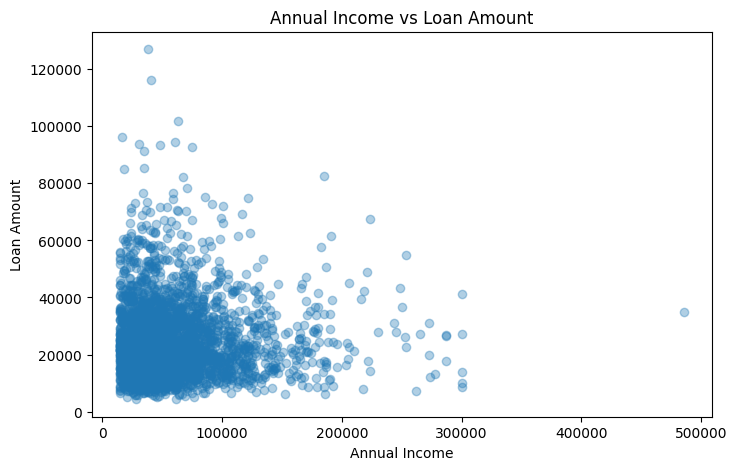

In [ ]:
sample = cleaned_data.sample(
    min(3000, len(cleaned_data)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    sample["AnnualIncome"],
    sample["LoanAmount"],
    alpha=0.35
)

ax.set_title("Annual Income vs Loan Amount")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Loan Amount")

plt.show()

## 18. Correlation Heatmap – Multivariate Analysis

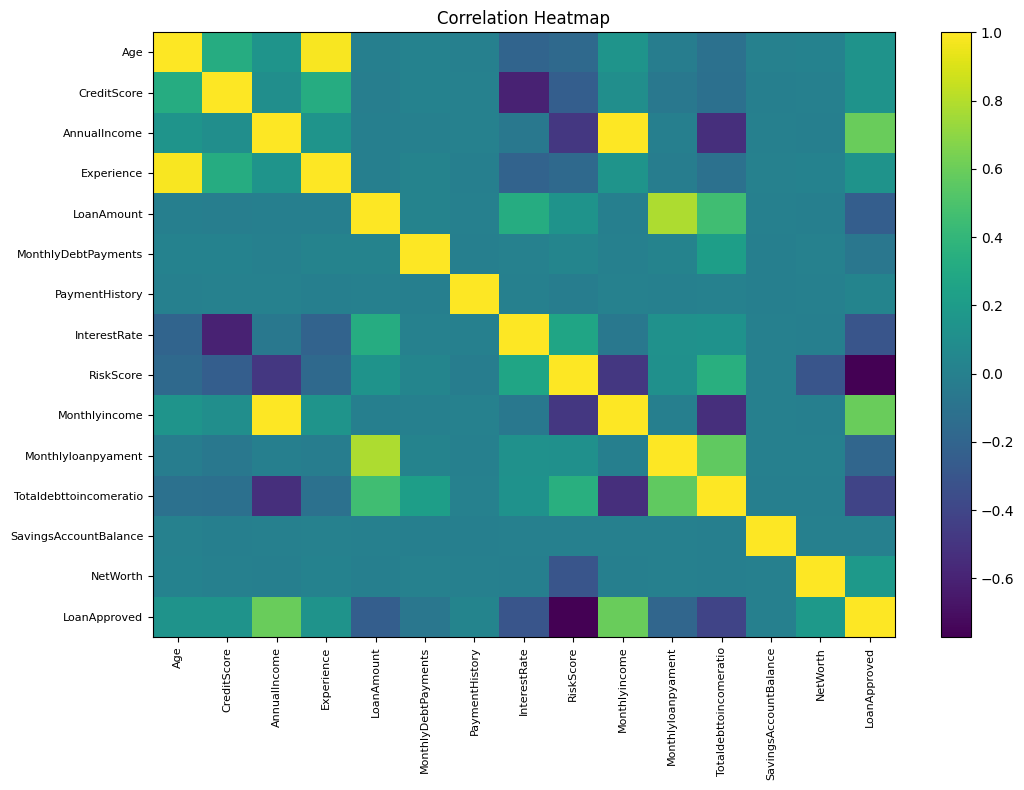

In [ ]:
correlation_columns = [
    "Age",
    "CreditScore",
    "AnnualIncome",
    "Experience",
    "LoanAmount",
    "MonthlyDebtPayments",
    "PaymentHistory",
    "InterestRate",
    "RiskScore",
    "Monthlyincome",
    "Monthlyloanpyament",
    "Totaldebttoincomeratio",
    "SavingsAccountBalance",
    "NetWorth",
    "LoanApproved"
]

correlation_matrix = cleaned_data[
    correlation_columns
].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8))

image = ax.imshow(
    correlation_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index,
    fontsize=8
)

ax.set_title("Correlation Heatmap")

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

# Model Development

## 19. Prepare the Loan Approval Model

`LoanApproved` is binary (`0` or `1`) and the brief asks for accuracy, precision, recall and F1.  
For that reason this notebook uses **Logistic Regression as a binary classification model**.

If your lecturer specifically means a continuous-value regression model when saying “regression analysis,” confirm that requirement with them.

In [ ]:
model_features = [
    "Age",
    "CreditScore",
    "AnnualIncome",
    "EmploymentStatus",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "MonthlyDebtPayments",
    "PreviousLoanDefaults",
    "PaymentHistory",
    "InterestRate",
    "RiskScore",
    "Totaldebttoincomeratio"
]

X = cleaned_data[model_features].copy()
y = cleaned_data["LoanApproved"].astype(int)

numeric_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = [
    column
    for column in model_features
    if column not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Age', 'CreditScore', 'AnnualIncome', 'Experience', 'LoanAmount', 'LoanDuration', 'MonthlyDebtPayments', 'PreviousLoanDefaults', 'PaymentHistory', 'InterestRate', 'RiskScore', 'Totaldebttoincomeratio']

Categorical features:
['EmploymentStatus']


## 20. Preprocessing Pipeline for Machine Learning

In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 21. Train / Validation / Test Split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Test rows:", len(X_test))

Training rows: 12800
Validation rows: 3200
Test rows: 4000


## 22. Build the Logistic Regression Model

In [ ]:
loan_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

loan_model.fit(
    X_train,
    y_train
)

print("Loan approval model trained.")

Loan approval model trained.


## 23. Baseline Model Evaluation

In [ ]:
test_probability = loan_model.predict_proba(
    X_test
)[:, 1]

baseline_prediction = (
    test_probability >= 0.50
).astype(int)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

baseline_precision = precision_score(
    y_test,
    baseline_prediction,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_prediction,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_prediction,
    zero_division=0
)

baseline_auc = roc_auc_score(
    y_test,
    test_probability
)

print("Baseline Accuracy :", round(baseline_accuracy, 4))
print("Baseline Precision:", round(baseline_precision, 4))
print("Baseline Recall   :", round(baseline_recall, 4))
print("Baseline F1       :", round(baseline_f1, 4))
print("Baseline ROC-AUC  :", round(baseline_auc, 4))

Baseline Accuracy : 0.9928
Baseline Precision: 0.9905
Baseline Recall   : 0.9791
Baseline F1       : 0.9847
Baseline ROC-AUC  : 0.9997


## 24. Model Improvement – Tune the Probability Threshold

In [ ]:
validation_probability = (
    loan_model.predict_proba(
        X_validation
    )[:, 1]
)

thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

best_threshold = 0.50
best_validation_f1 = -1

for threshold in thresholds:

    prediction = (
        validation_probability >= threshold
    ).astype(int)

    score = f1_score(
        y_validation,
        prediction,
        zero_division=0
    )

    if score > best_validation_f1:
        best_validation_f1 = score
        best_threshold = threshold

print(
    "Best threshold:",
    round(float(best_threshold), 2)
)

print(
    "Best validation F1:",
    round(float(best_validation_f1), 4)
)

Best threshold: 0.47
Best validation F1: 0.9856


## 25. Evaluate the Improved Threshold

In [ ]:
improved_prediction = (
    test_probability >= best_threshold
).astype(int)

improved_accuracy = accuracy_score(
    y_test,
    improved_prediction
)

improved_precision = precision_score(
    y_test,
    improved_prediction,
    zero_division=0
)

improved_recall = recall_score(
    y_test,
    improved_prediction,
    zero_division=0
)

improved_f1 = f1_score(
    y_test,
    improved_prediction,
    zero_division=0
)

results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Threshold": 0.50,
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1": baseline_f1,
        "ROC-AUC": baseline_auc
    },
    {
        "Model": "Improved",
        "Threshold": best_threshold,
        "Accuracy": improved_accuracy,
        "Precision": improved_precision,
        "Recall": improved_recall,
        "F1": improved_f1,
        "ROC-AUC": baseline_auc
    }
])

display(
    results.round(4)
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.50,0.9928,0.9905,0.9791,0.9847,0.9997
1,Improved,0.47,0.9930,0.9884,0.9822,0.9853,0.9997


## 26. Confusion Matrix

[[3033   11]
 [  17  939]]


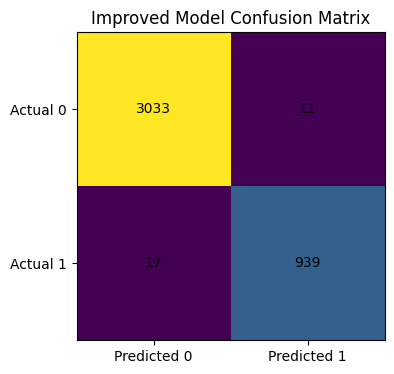

In [ ]:
cm = confusion_matrix(
    y_test,
    improved_prediction
)

print(cm)

fig, ax = plt.subplots(figsize=(5, 4))

image = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Predicted 0", "Predicted 1"]
)

ax.set_yticklabels(
    ["Actual 0", "Actual 1"]
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

ax.set_title(
    "Improved Model Confusion Matrix"
)

plt.show()

# Customer Segmentation with K-Means

## 27. Build the K-Means Model

In [ ]:
cluster_features = [
    "RiskScore",
    "CreditScore",
    "Monthlyincome",
    "LoanAmount",
    "Totaldebttoincomeratio",
    "SavingsAccountBalance",
    "NetWorth"
]

cluster_X = cleaned_data[
    cluster_features
].copy()

cluster_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "kmeans",
        KMeans(
            n_clusters=3,
            random_state=42,
            n_init=20
        )
    )
])

cleaned_data["Cluster"] = (
    cluster_pipeline.fit_predict(
        cluster_X
    )
)

print(
    cleaned_data["Cluster"]
    .value_counts()
    .sort_index()
)

Cluster
0    11198
1     3399
2     5403
Name: count, dtype: int64


## 28. Understand and Label the Clusters

In [ ]:
cluster_profile = (
    cleaned_data
    .groupby("Cluster")[
        cluster_features
        + ["LoanApproved"]
    ]
    .mean()
    .round(2)
)

display(cluster_profile)

# Use historical approval rate only to give simple,
# understandable business labels to the clusters.
approval_by_cluster = (
    cleaned_data
    .groupby("Cluster")["LoanApproved"]
    .mean()
    .sort_values()
)

ordered_clusters = (
    approval_by_cluster.index.tolist()
)

cluster_label_map = {
    ordered_clusters[0]: "High Risk",
    ordered_clusters[1]: "Moderate Risk",
    ordered_clusters[2]: "Low Risk"
}

cleaned_data["RiskSegment"] = (
    cleaned_data["Cluster"]
    .map(cluster_label_map)
)

display(
    cleaned_data[
        [
            "ID",
            "Cluster",
            "RiskSegment",
            "RiskScore",
            "CreditScore",
            "LoanApproved"
        ]
    ].head(20)
)

,RiskScore,CreditScore,Monthlyincome,LoanAmount,Totaldebttoincomeratio,SavingsAccountBalance,NetWorth,LoanApproved
Cluster,,,,,,,,
0,54.28,565.89,3825.14,21176.70,35.88,4825.99,51394.46,0.02
1,54.25,562.11,2971.13,43398.78,91.59,5213.49,70015.42,0.00
2,40.70,589.45,8452.66,20915.84,16.27,5026.63,117044.02,0.84


,ID,Cluster,RiskSegment,RiskScore,CreditScore,LoanApproved
0,A001,0,Moderate Risk,49.0,617,0
1,A002,0,Moderate Risk,51.0,628,0
2,A003,0,Moderate Risk,51.0,570,0
3,A004,0,Moderate Risk,54.0,545,0
4,A005,2,Low Risk,36.0,594,1
5,A006,2,Low Risk,44.0,626,1
6,A007,0,Moderate Risk,50.0,564,0
7,A008,2,Low Risk,42.0,516,1
8,A009,1,High Risk,61.0,603,0
9,A010,1,High Risk,53.0,612,0


## 29. Evaluate K-Means with Silhouette Score

In [ ]:
cluster_imputed = (
    cluster_pipeline
    .named_steps["imputer"]
    .transform(cluster_X)
)

cluster_scaled = (
    cluster_pipeline
    .named_steps["scaler"]
    .transform(cluster_imputed)
)

silhouette = silhouette_score(
    cluster_scaled,
    cleaned_data["Cluster"],
    sample_size=min(
        5000,
        len(cleaned_data)
    ),
    random_state=42
)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

Silhouette Score: 0.2089


# PCA Privacy Demonstration

## 30. Apply PCA to Selected Sensitive Financial Columns

In [ ]:
sensitive_columns = [
    "AnnualIncome",
    "SavingsAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "NetWorth"
]

pca_X = cleaned_data[
    sensitive_columns
].copy()

pca_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "pca",
        PCA(n_components=2)
    )
])

pca_components = (
    pca_pipeline.fit_transform(
        pca_X
    )
)

pca_data = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "LoanApproved": cleaned_data[
        "LoanApproved"
    ].values
})

explained_variance = (
    pca_pipeline
    .named_steps["pca"]
    .explained_variance_ratio_
)

print(
    "PC1 explained variance:",
    round(
        explained_variance[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2 explained variance:",
    round(
        explained_variance[1] * 100,
        2
    ),
    "%"
)

print(
    "Combined:",
    round(
        explained_variance.sum() * 100,
        2
    ),
    "%"
)

display(pca_data.head())

PC1 explained variance: 39.75 %
PC2 explained variance: 20.06 %
Combined: 59.81 %


,PC1,PC2,LoanApproved
0,0.652599,-0.140917,0
1,-0.370516,0.077612,0
2,-1.003153,-1.608638,0
3,0.264068,0.641497,0
4,1.809116,0.976369,1


## 31. Visualise the PCA Components

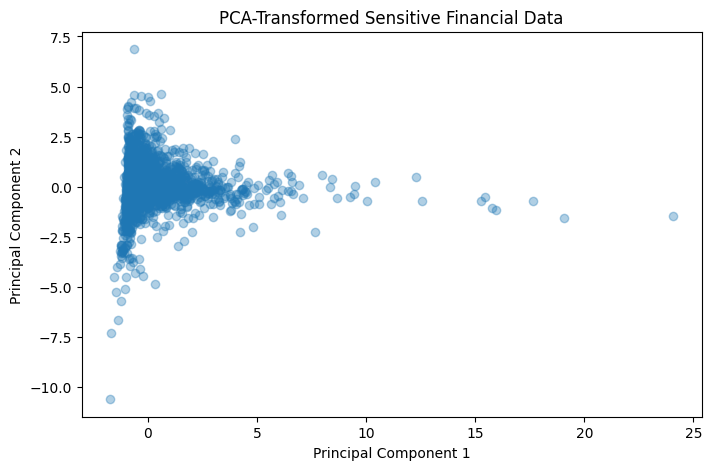

In [ ]:
sample_pca = pca_data.sample(
    min(3000, len(pca_data)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    sample_pca["PC1"],
    sample_pca["PC2"],
    alpha=0.35
)

ax.set_title(
    "PCA-Transformed Sensitive Financial Data"
)

ax.set_xlabel(
    "Principal Component 1"
)

ax.set_ylabel(
    "Principal Component 2"
)

plt.show()

### PCA discussion

PCA combines several original variables into new principal components.  
This can reduce direct exposure of individual financial values during analysis.

However, **PCA is not encryption or full anonymisation**. It should be considered only one possible privacy-supporting transformation alongside proper access control and data-governance measures.

# Save Models and Outputs

## 32. Export the Models and Results

In [ ]:
joblib.dump(
    loan_model,
    "loan_approval_model.joblib"
)

joblib.dump(
    cluster_pipeline,
    "kmeans_customer_segmentation.joblib"
)

joblib.dump(
    pca_pipeline,
    "pca_privacy_model.joblib"
)

cleaned_data.to_csv(
    "final_loan_data_with_segments.csv",
    index=False
)

results.to_csv(
    "model_performance.csv",
    index=False
)

cluster_profile.to_csv(
    "cluster_profile.csv"
)

print("All models and output files saved.")

All models and output files saved.


## 33. Optional – Download the Main Output Files

In [39]:
from google.colab import files

# Uncomment the file you want to download.

files.download("cleaned_loan_data.csv")
files.download("loan_approval_model.joblib")
files.download("kmeans_customer_segmentation.joblib")
files.download("pca_privacy_model.joblib")
files.download("model_performance.csv")
files.download("final_loan_data_with_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>